# Stage 60 — Matrizes de confusão

Objetivo: interpretar os resultados da SVM por participante e para o grupo. Linhas são classes verdadeiras; colunas são previsões.


## 1. Importações


In [2]:
from pathlib import Path
import pickle
import re

import matplotlib.pyplot as plt
import numpy as np


## 2. Caminhos e nomes das classes

A ordem segue os rótulos do dataset: `0=Up`, `1=Down`, `2=Right`, `3=Left`.


In [6]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

k_features = 3

INPUT_DIR = PROJECT_ROOT / "processed_data" / f"stage_03_svm"/ f"k_features_{k_features}" / "stage_03_svm"
OUTPUT_DIR = PROJECT_ROOT / "results" / "stage_04_generate_results" / "confusion_matrices"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["Up", "Down", "Right", "Left"]


## 3. Carregar os arquivos `.pkl`


In [5]:
def subject_number(path):
    return int(re.search(r"sub-(\d+)", path.name).group(1))

result_files = sorted(
    INPUT_DIR.glob("sub-*_svm_results*.pkl"),
    key=subject_number,
)

results = {}
for result_path in result_files:
    with result_path.open("rb") as file:
        results.update(pickle.load(file))

if not results:
    raise FileNotFoundError(f"Nenhum resultado encontrado em {INPUT_DIR}")

subjects = list(results)
print("Participantes carregados:", subjects)


FileNotFoundError: Nenhum resultado encontrado em /home/jobson/Documentos/DSP_classifier/DSP-classifier/processed_data/k_features_3/stage_03_svm

## 4. Extrair e inspecionar as matrizes


In [84]:
matrices = np.array([
    results[subject]["mean_confusion_matrix"]
    for subject in subjects
])

print("Formato (participantes, classes, classes):", matrices.shape)
print(f"Matriz de {subjects[0]}:\n", matrices[0])
print("Soma de cada linha:", matrices[0].sum(axis=1))


Formato (participantes, classes, classes): (10, 4, 4)
Matriz de sub-01:
 [[0.38 0.3  0.2  0.12]
 [0.2  0.34 0.2  0.26]
 [0.38 0.36 0.1  0.16]
 [0.18 0.46 0.18 0.18]]
Soma de cada linha: [1. 1. 1. 1.]


## 5. Funções auxiliares para desenhar


In [85]:
def annotate_matrix(ax, matrix):
    for row in range(len(CLASS_NAMES)):
        for column in range(len(CLASS_NAMES)):
            value = matrix[row, column]
            color = "white" if value > 0.5 else "black"
            ax.text(
                column, row, f"{value:.2f}",
                ha="center", va="center", color=color, fontsize=8,
            )


def configure_axis(ax, title):
    ticks = np.arange(len(CLASS_NAMES))
    ax.set_xticks(ticks, CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticks(ticks, CLASS_NAMES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title, fontsize=10)


## 6. Desenhar uma única matriz

Esta célula ajuda a compreender o gráfico antes da figura completa.


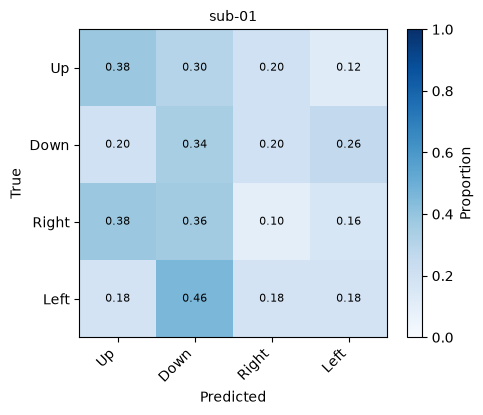

In [86]:
subject = subjects[0]
matrix = results[subject]["mean_confusion_matrix"]

fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(matrix, vmin=0, vmax=1, cmap="Blues")
annotate_matrix(ax, matrix)
configure_axis(ax, subject)
fig.colorbar(image, ax=ax, label="Proportion")
plt.show()


## 7. Gerar a figura dos participantes


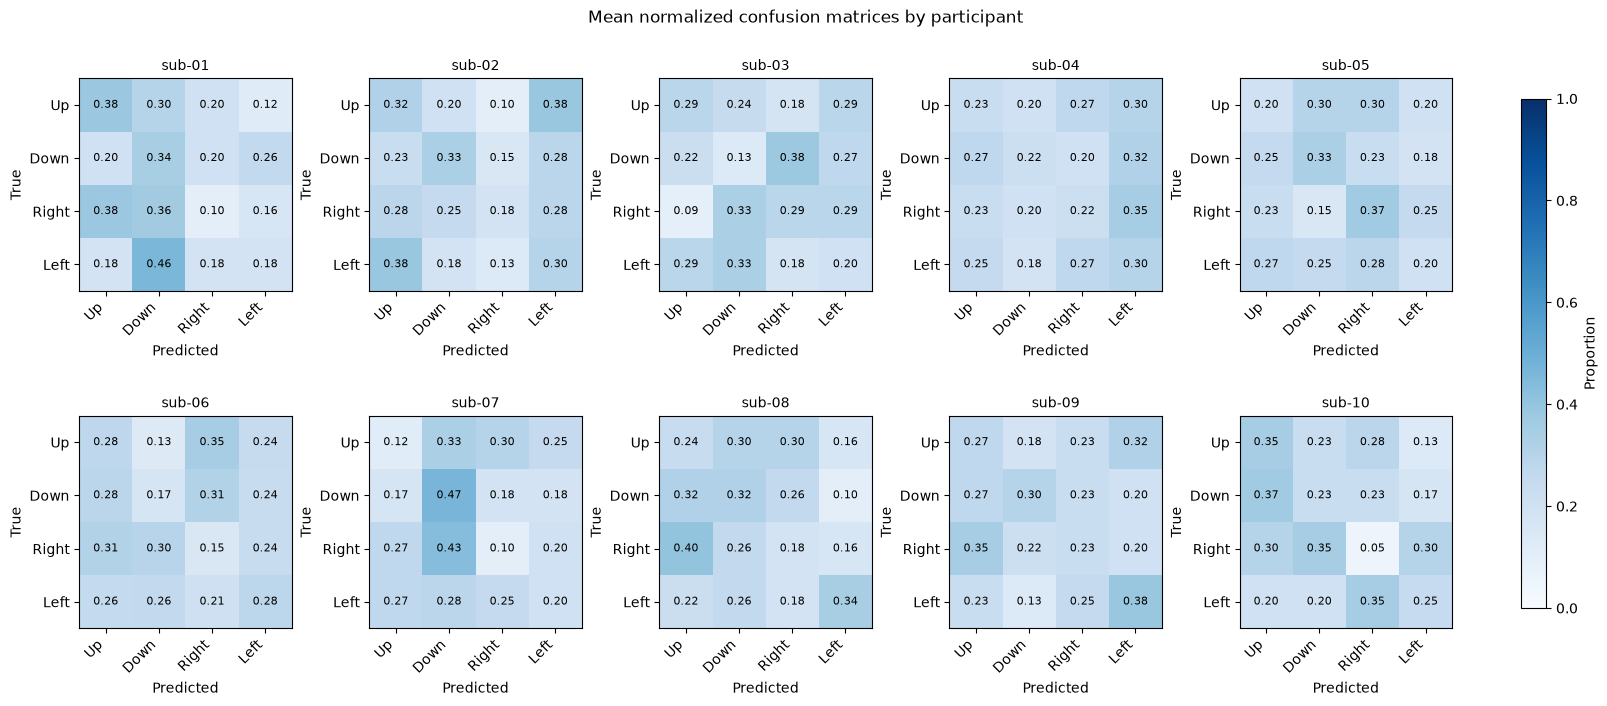

In [87]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7), constrained_layout=True)

for ax, subject, matrix in zip(axes.ravel(), subjects, matrices):
    image = ax.imshow(matrix, vmin=0, vmax=1, cmap="Blues")
    annotate_matrix(ax, matrix)
    configure_axis(ax, subject)

fig.suptitle("Mean normalized confusion matrices by participant")
fig.colorbar(image, ax=axes, shrink=0.8, label="Proportion")
fig.savefig(
    OUTPUT_DIR / "confusion_matrices_by_subject.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 8. Calcular e desenhar a matriz média do grupo

A média da diagonal é a balanced accuracy, pois cada linha representa o recall de uma classe.


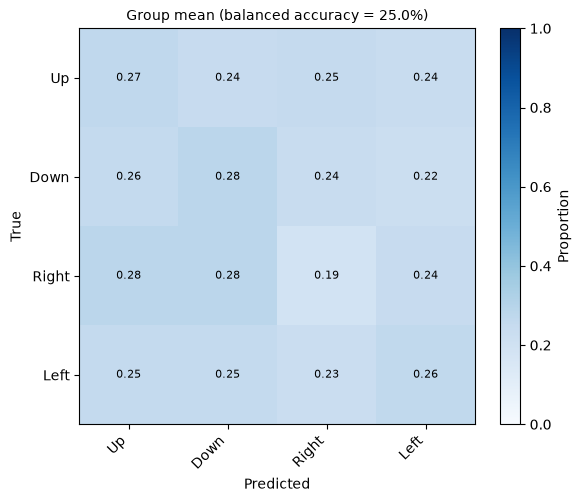

Figuras salvas em: /home/jobson/Documentos/DSP_classifier/DSP-classifier/results/stage_04_generate_results/confusion_matrices


In [88]:
group_matrix = matrices.mean(axis=0)
balanced_accuracy = np.diag(group_matrix).mean()

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(group_matrix, vmin=0, vmax=1, cmap="Blues")
annotate_matrix(ax, group_matrix)
configure_axis(
    ax,
    f"Group mean (balanced accuracy = {balanced_accuracy * 100:.1f}%)",
)
fig.colorbar(image, ax=ax, label="Proportion")
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "group_mean_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Figuras salvas em:", OUTPUT_DIR)
